In [5]:
import uproot
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt
from pathlib import Path
import mplhep
from cycler import cycler
plt.style.use(mplhep.style.CMS)
def get_hists(dc: str):
    with uproot.open(dc) as f:
        hists = { n.strip(';1') : (f[n].values(), np.arange(0,len(f[n].axis().edges()))) for n in f.classnames()}
    sig = hists.pop('ggHH_kl_1_kt_1_hbbhww')
    asimov = hists.pop('asimov')
    hists.pop("ggHH_kl_0_kt_1_hbbhww")
    hists.pop("ggHH_kl_2p45_kt_1_hbbhww")
    hists.pop("ggHH_kl_5_kt_1_hbbhww")
    hists.pop("ggHH_kl_0_kt_1_hbbhtt")
    hists.pop("ggHH_kl_1_kt_1_hbbhtt")
    hists.pop("ggHH_kl_2p45_kt_1_hbbhtt")
    hists.pop("ggHH_kl_5_kt_1_hbbhtt")
    return sig, hists

In [6]:
%config InlineBackend.figure_format = 'retina'

In [7]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',  # Original 10
          '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5',  # Lighter versions
          '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5']  # More light versions

Workdir: /eos/user/a/anunezde/Z_OUTPUT_eos/Final_Model/NNInf_roster_3j4j
Model name: multi_HH_ttbar_tWandWJets_u360
Processing selection: SL_3j_resolved


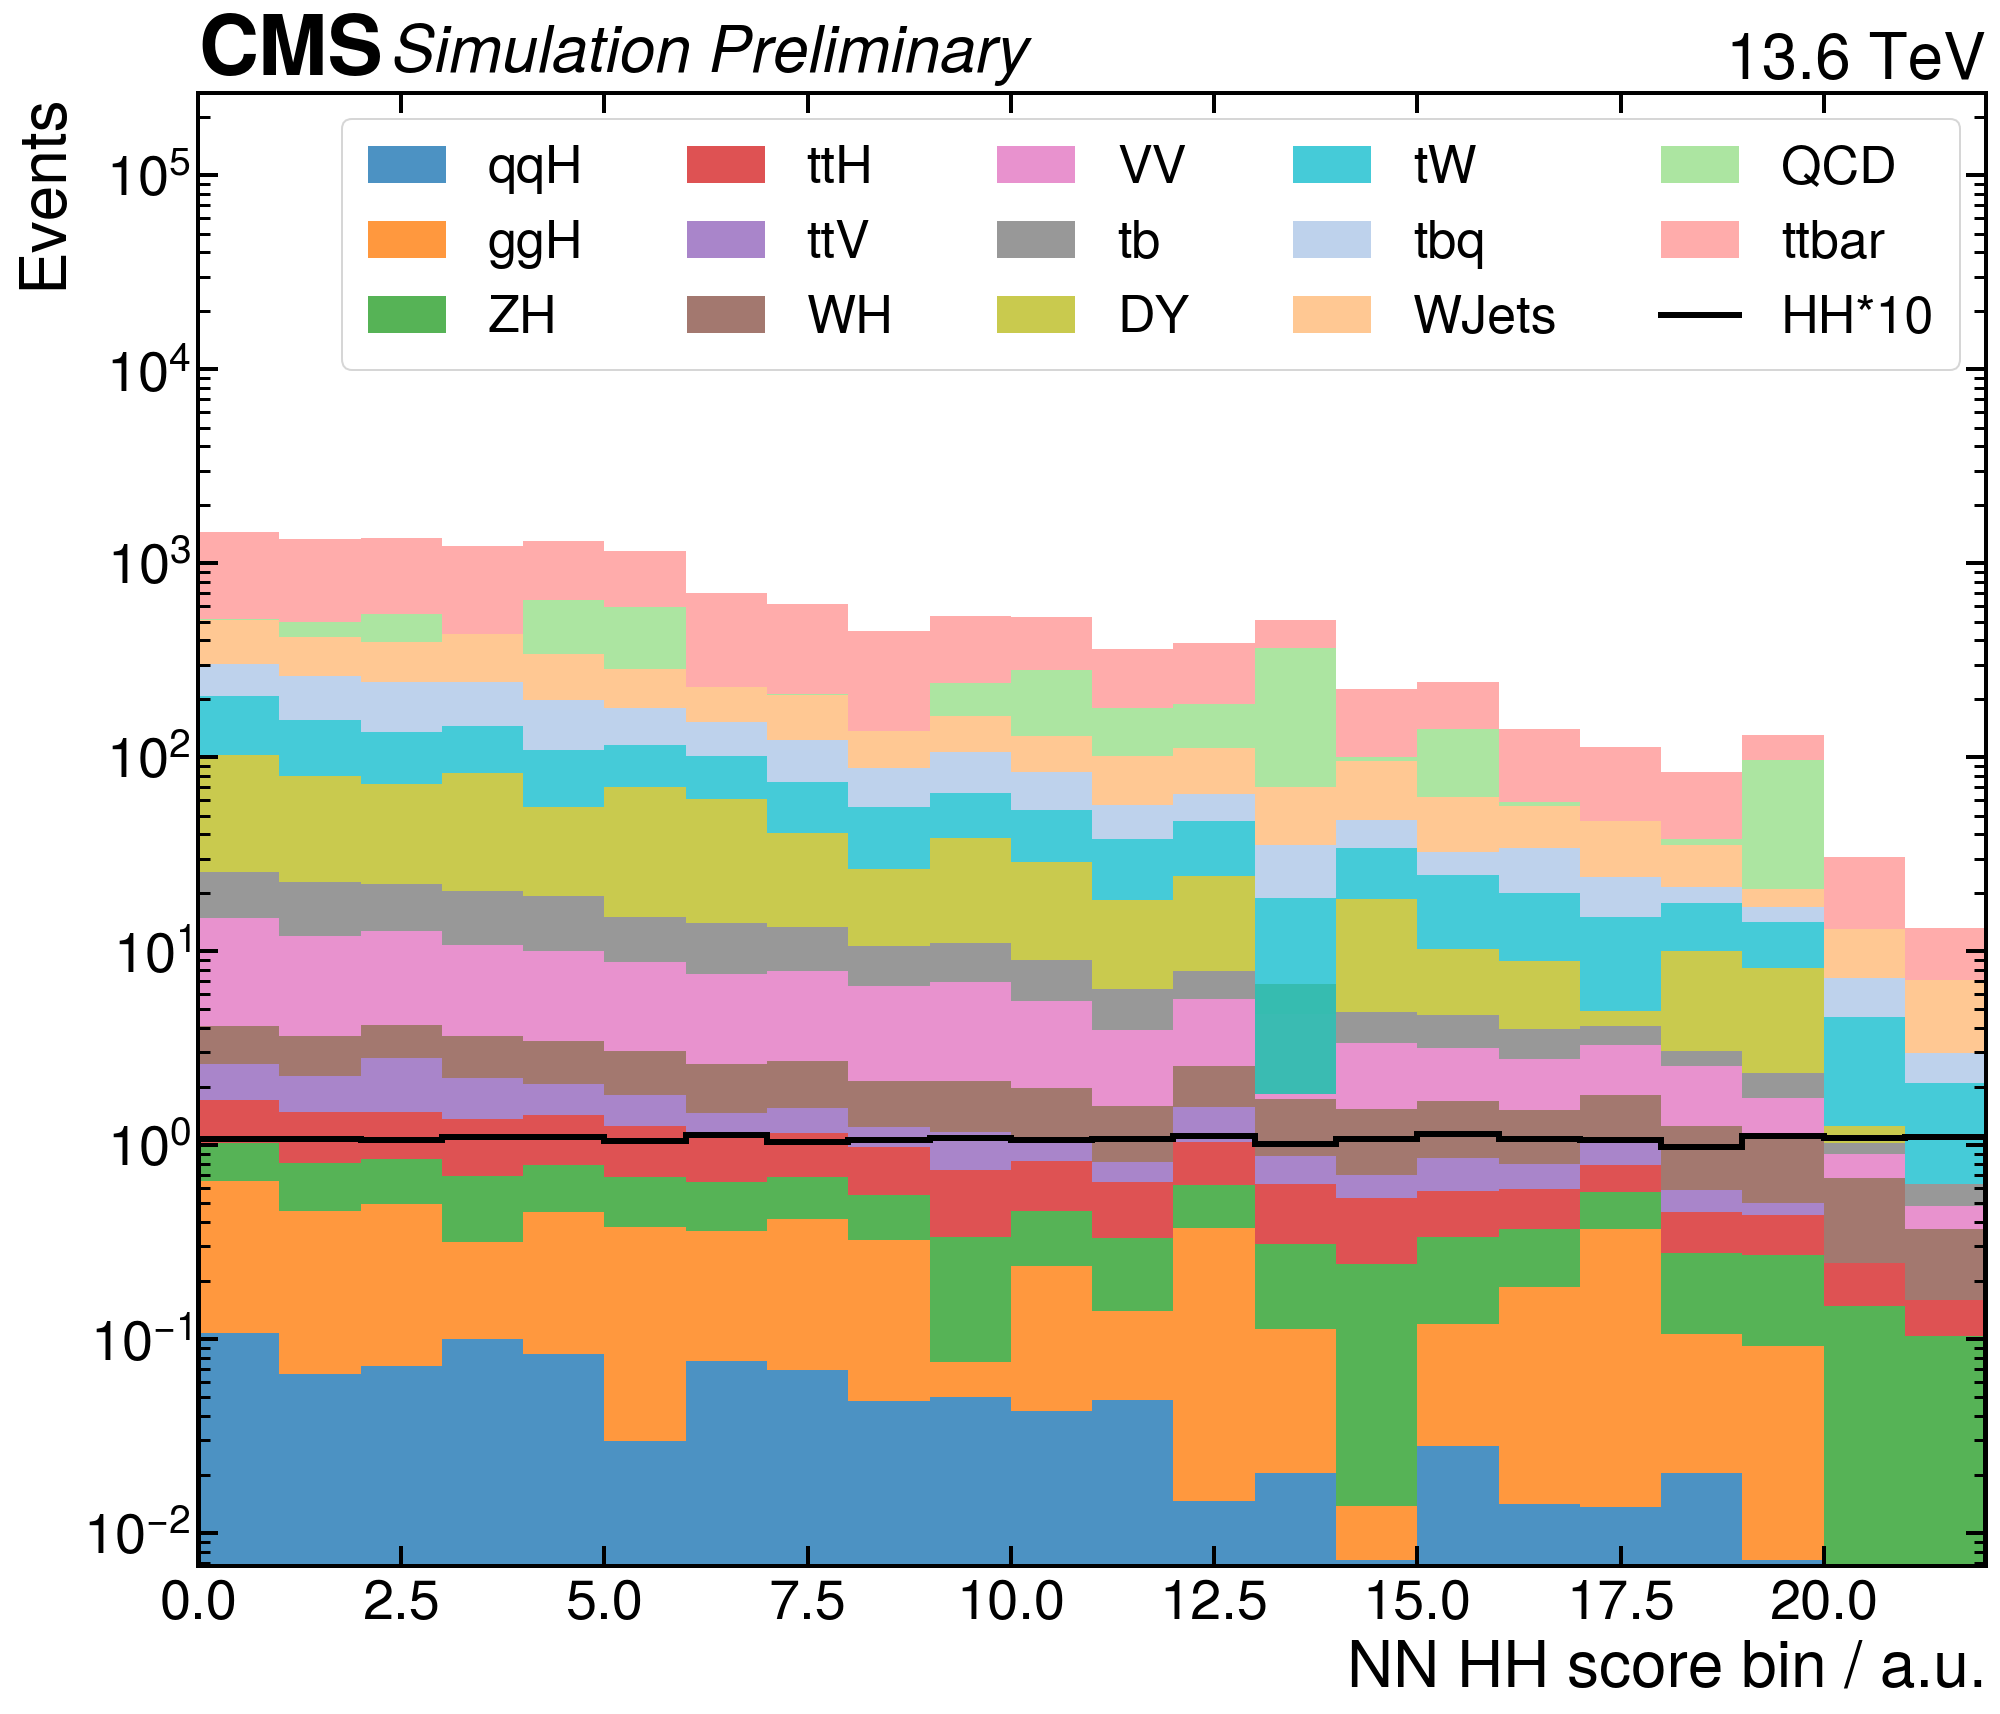

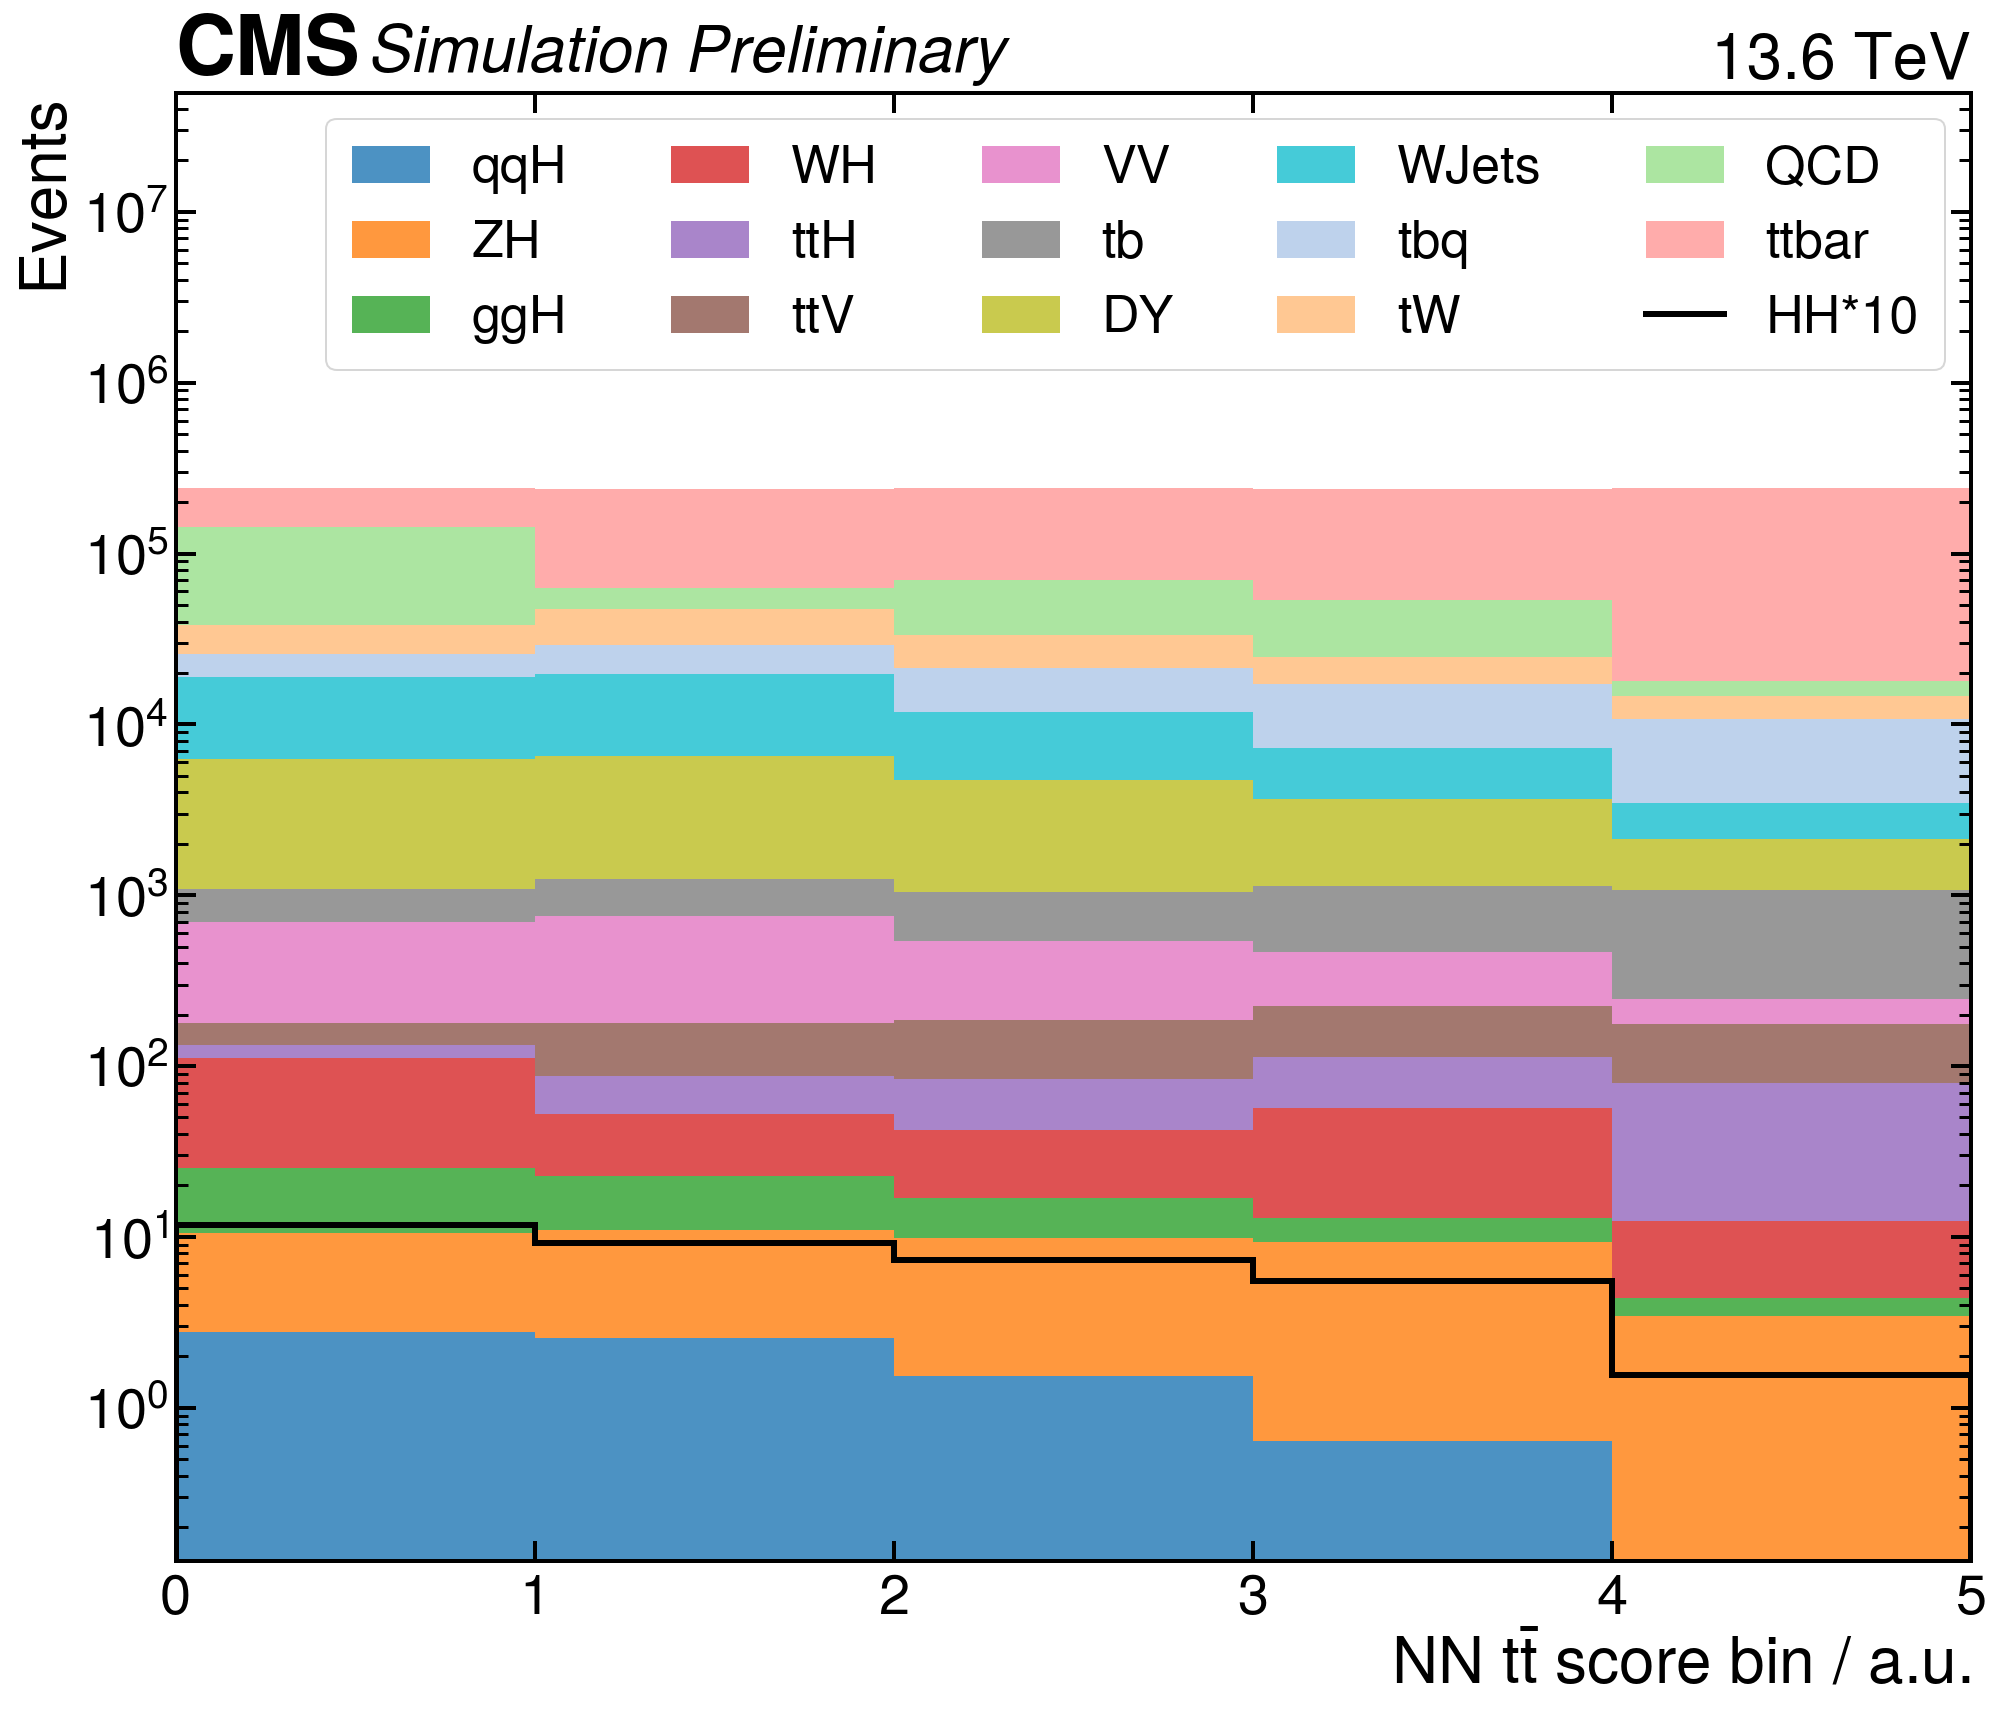

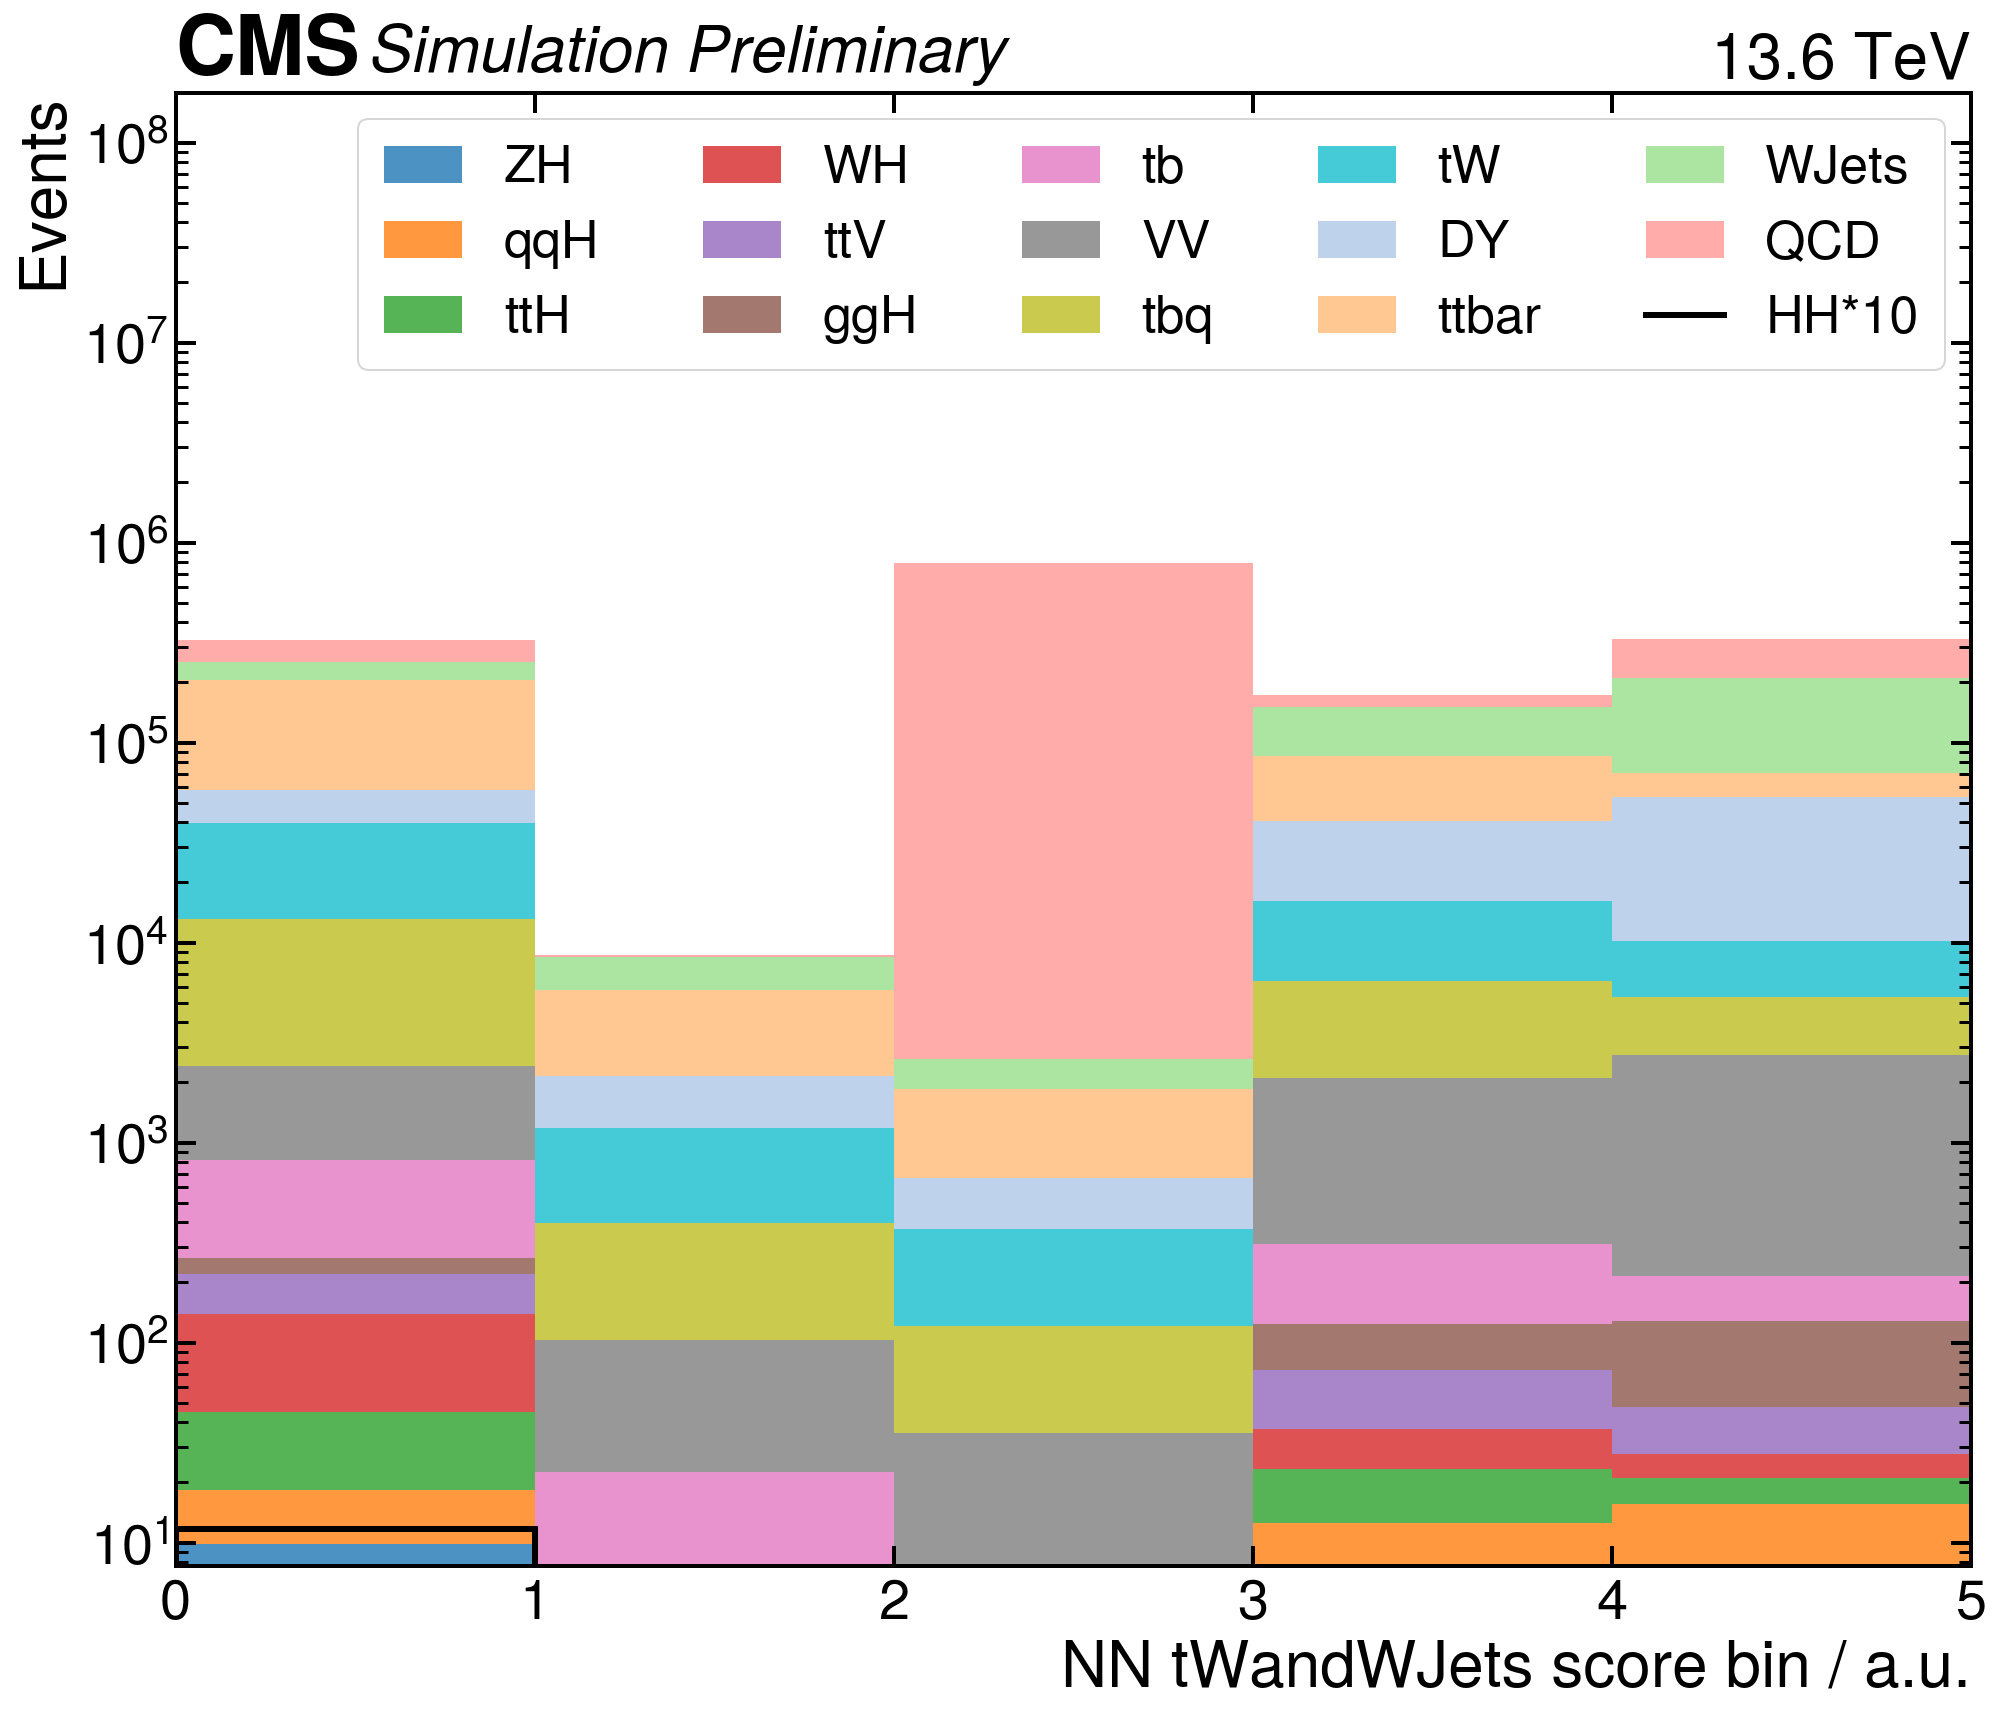

Processing selection: SL_4j_resolved


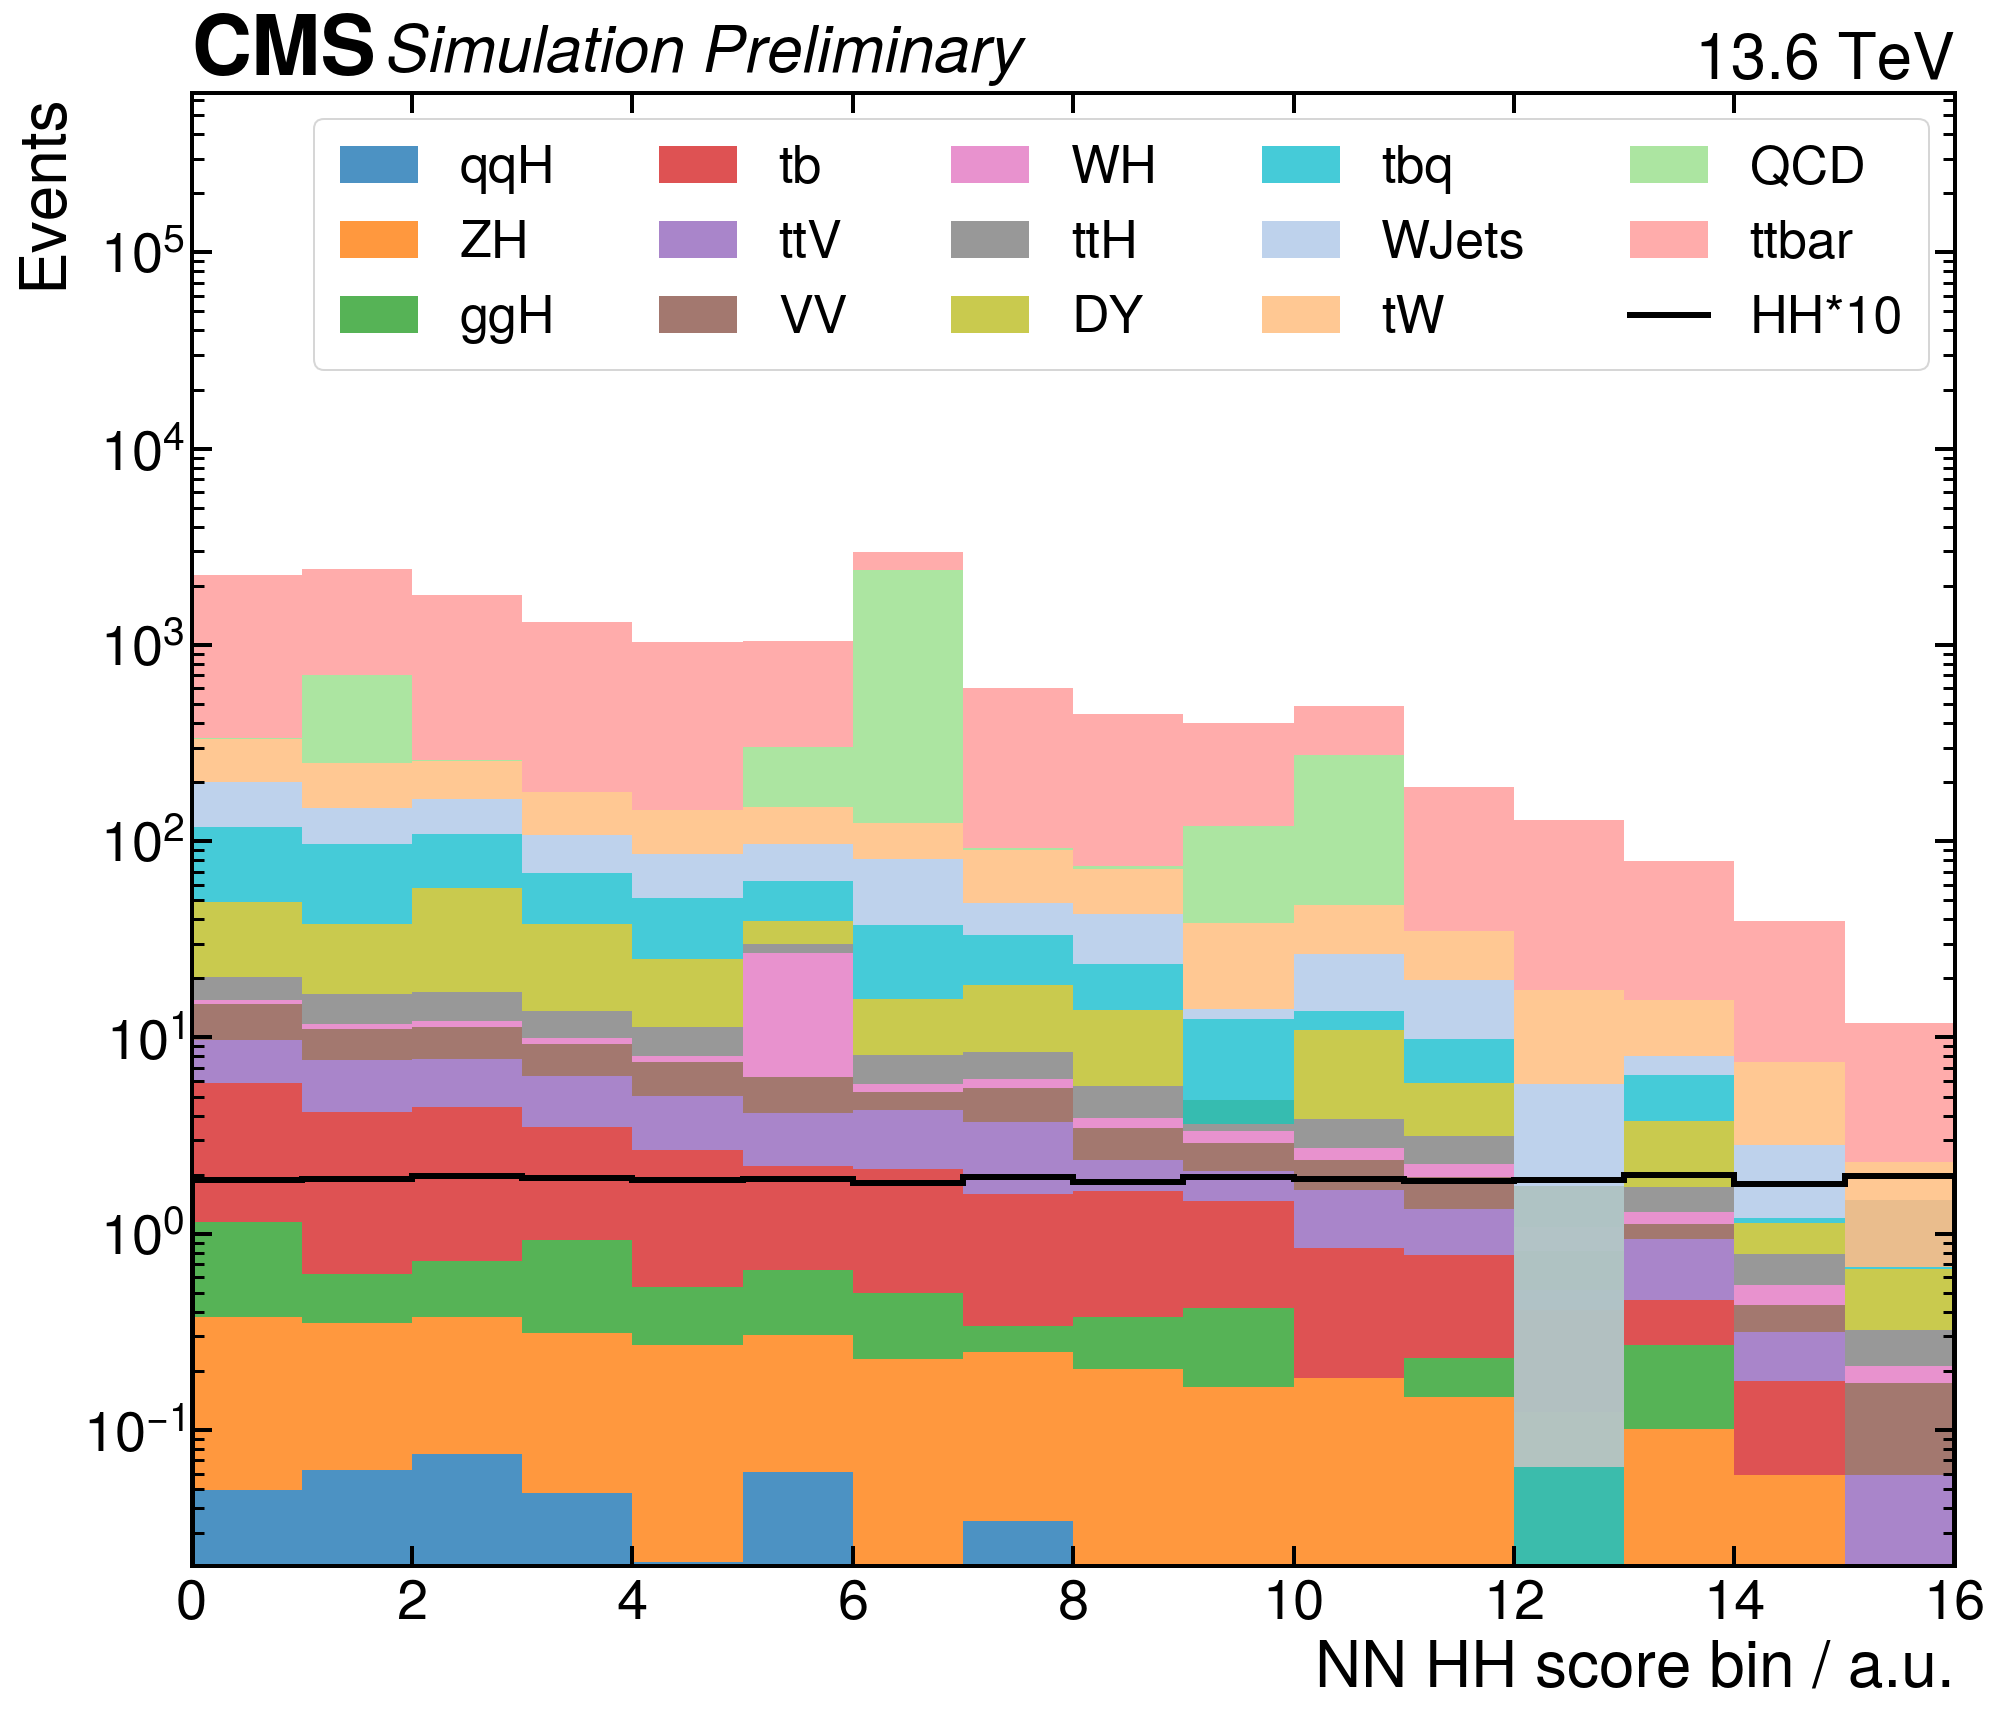

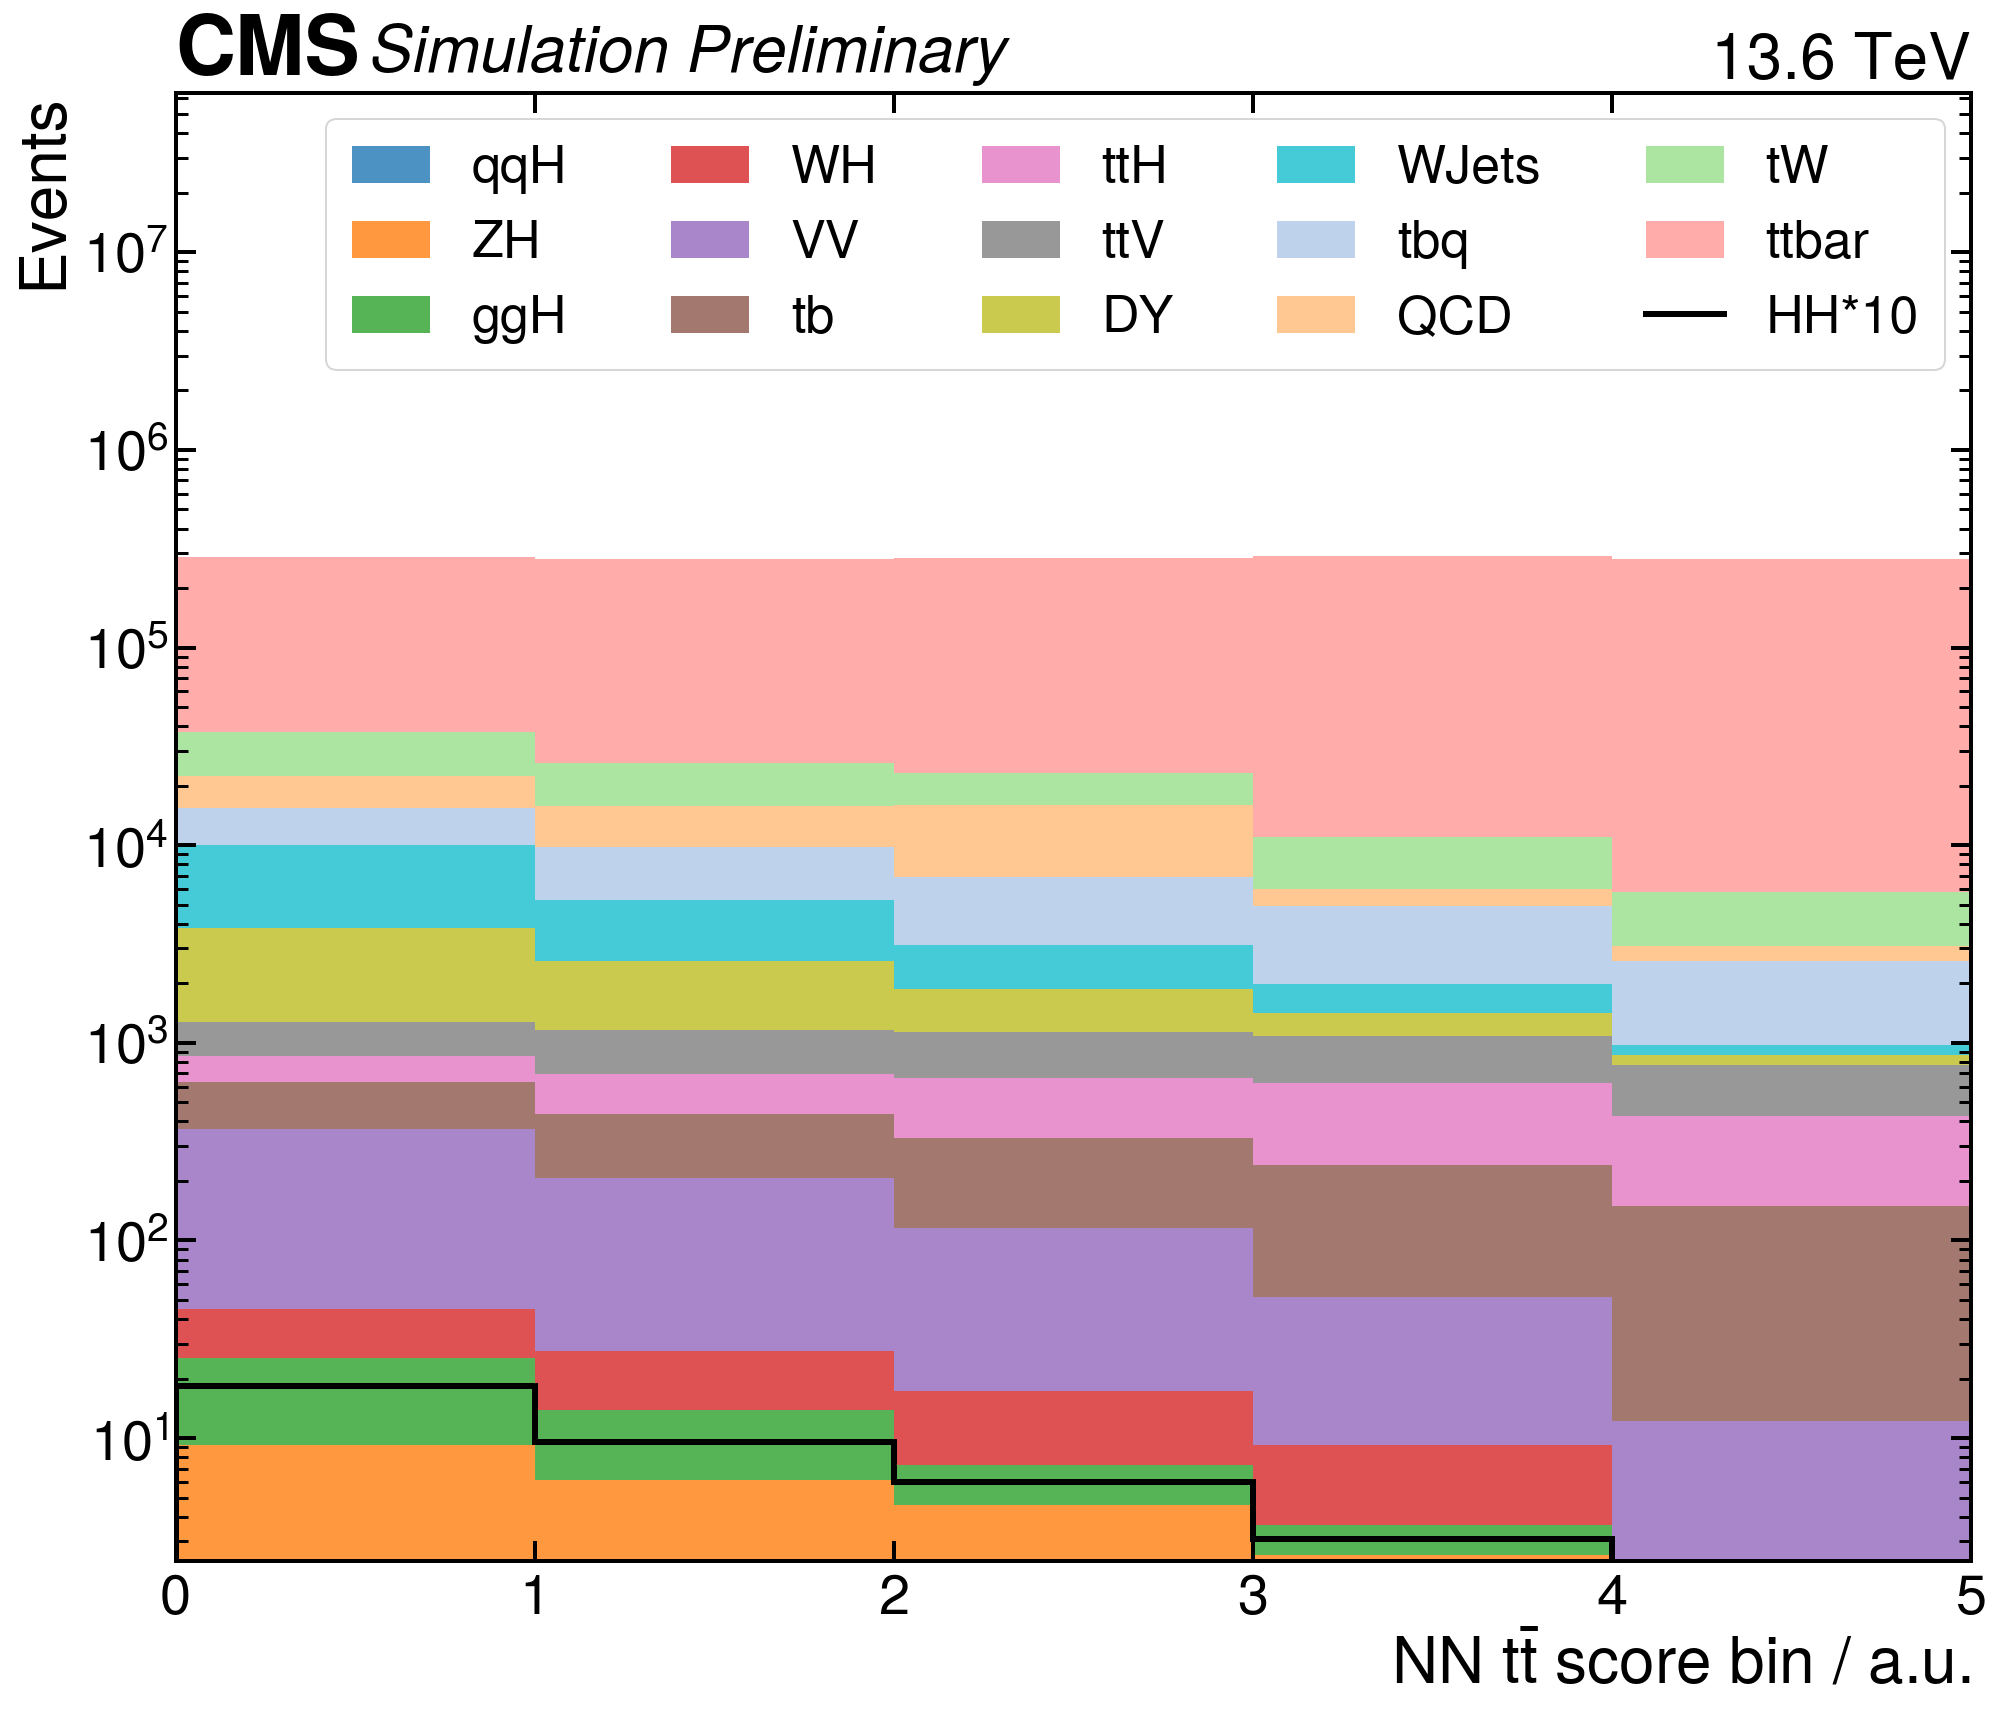

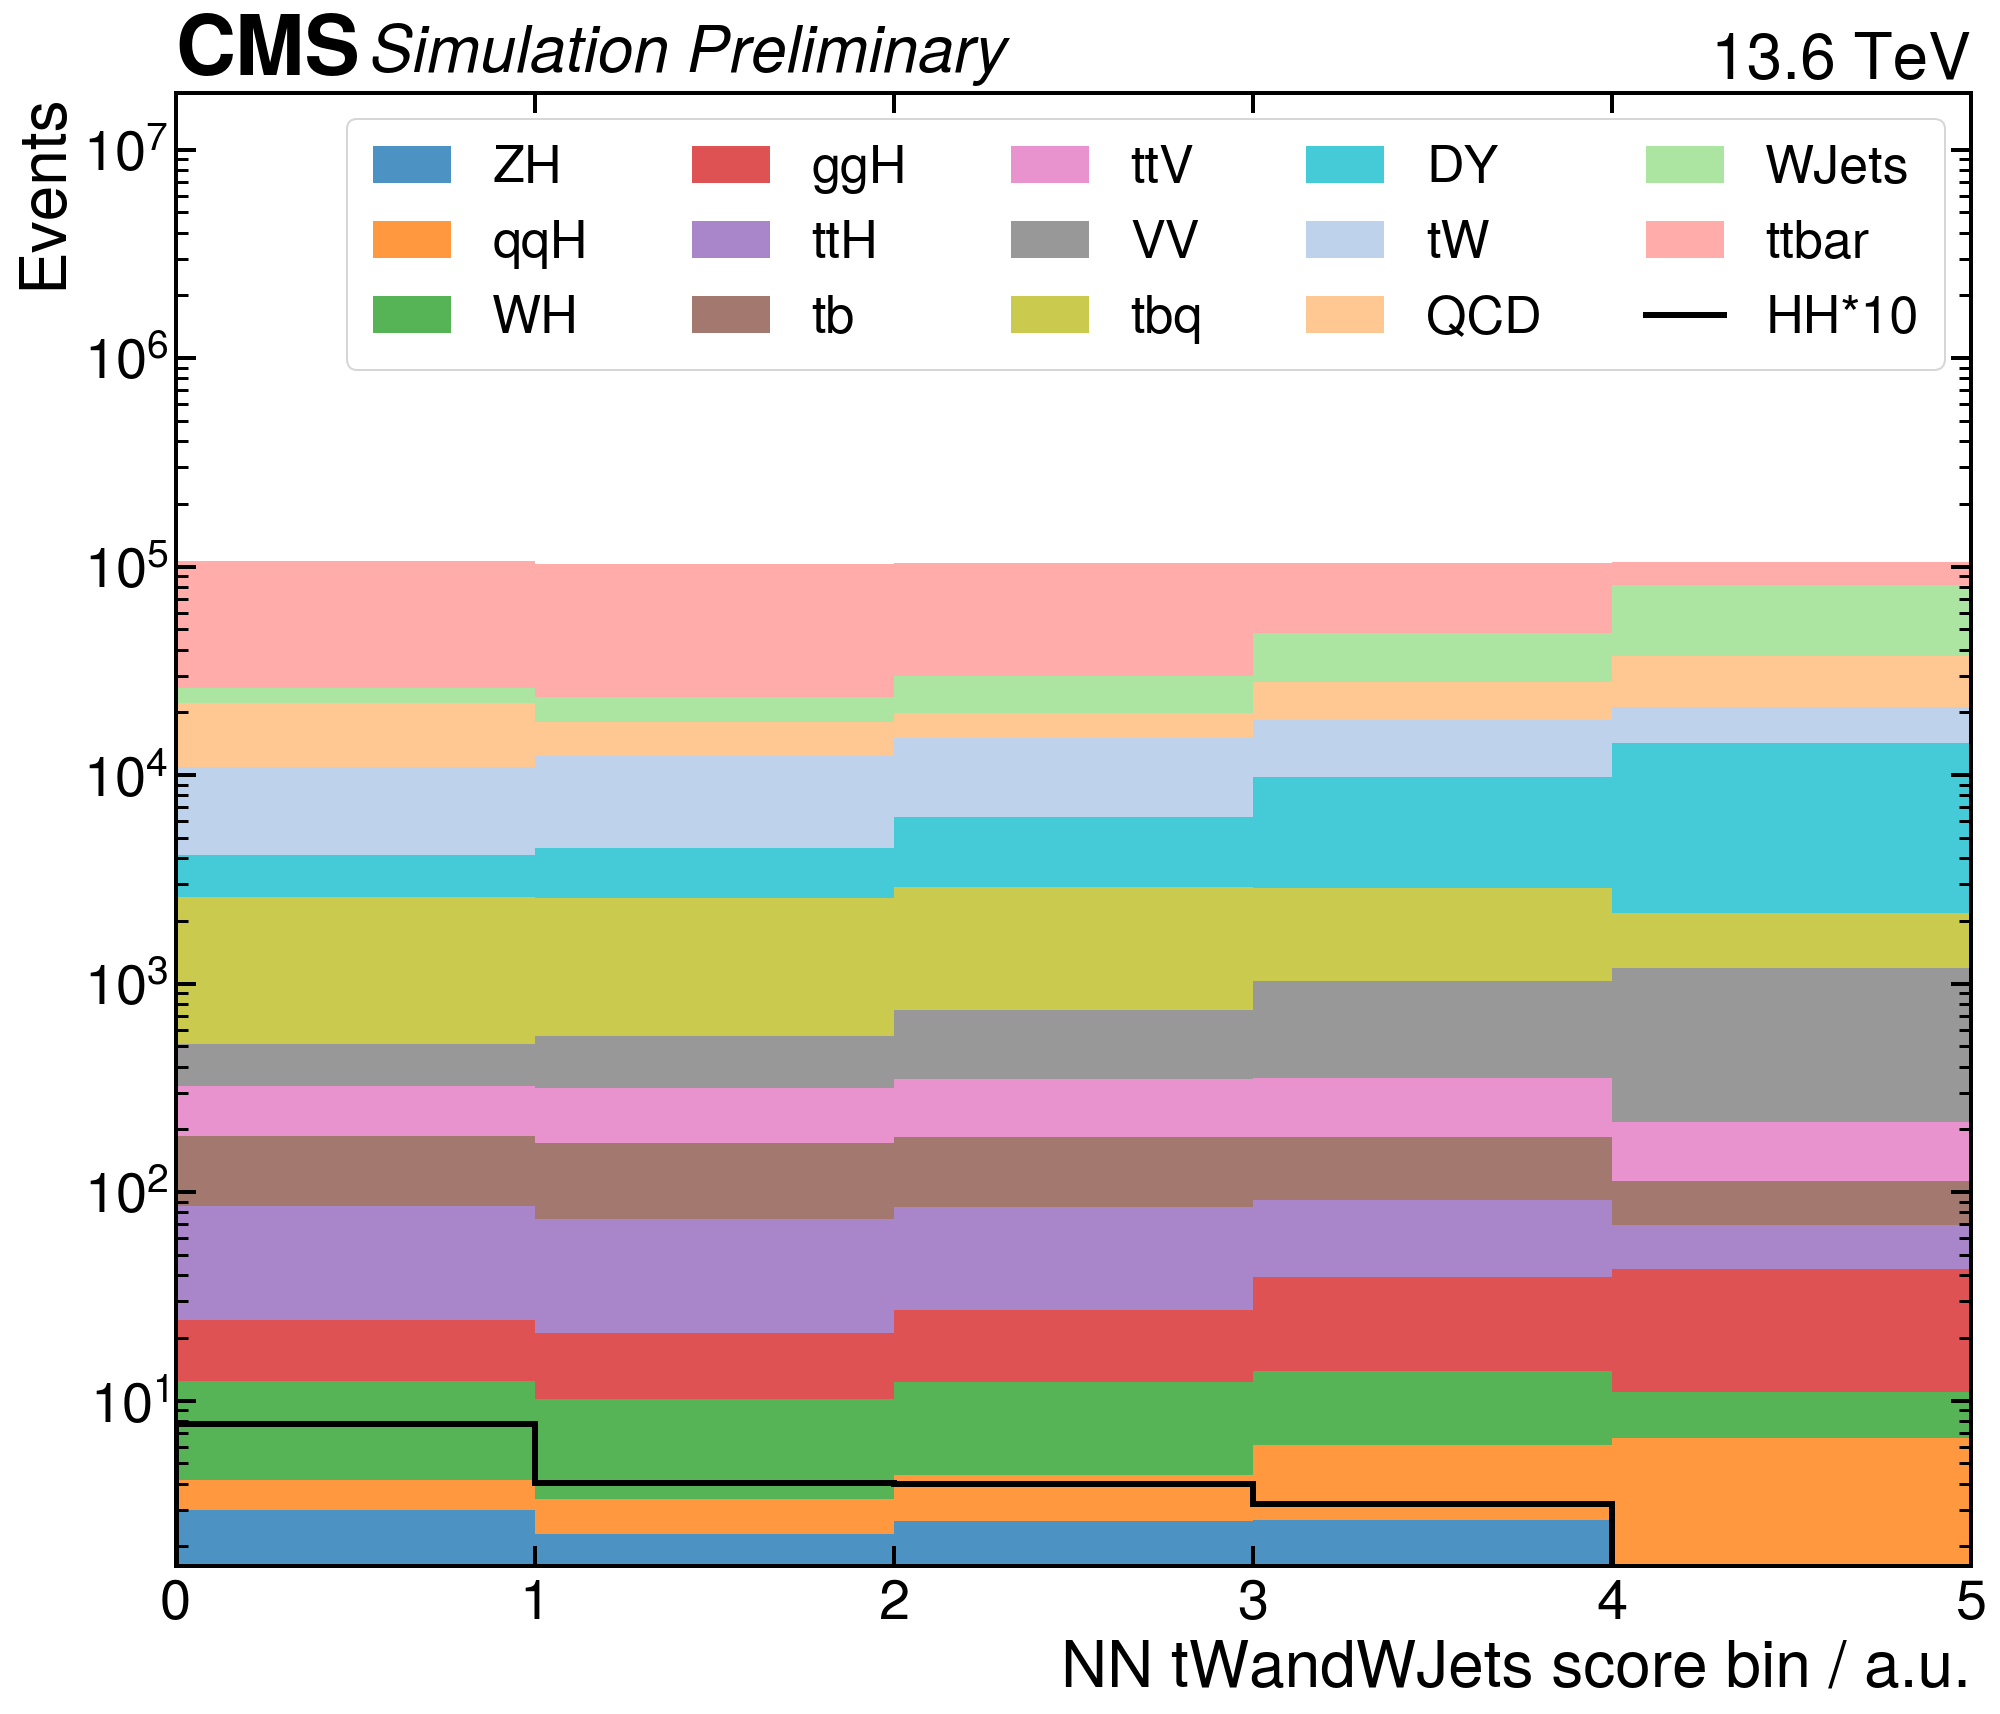

In [ ]:
signal_multiplier = 10

workdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Final_Model/NNInf_roster_3j4j')
model_name = "multi_HH_ttbar_tWandWJets_u360"

print(f'Workdir: {workdir}')
print(f'Model name: {model_name}')

sels = ['SL_3j_resolved', 'SL_4j_resolved']

for sel in sels:
    print(f'Processing selection: {sel}')
    model_fit_dir = workdir / "fits_final" / model_name
    signal_dc: str = model_fit_dir / "2022EE" / sel / 'HH' / "HH_score.root"
    ttbar_dc: str = model_fit_dir / "2022EE" / sel / 'ttbar' / "ttbar_score.root"
    tW_dc: str = model_fit_dir / "2022EE" / sel / 'tWandWJets' / "tWandWJets_score.root"

    data_files = [
        (signal_dc, r'NN HH score bin / a.u.', 'HH'),
        (ttbar_dc, r'NN t$\bar t$ score bin / a.u.', 'ttbar'),
        (tW_dc, r'NN tWandWJets score bin / a.u.', 'tWandWJets')
    ]

    OUTDIR = workdir / 'prefit_plots' / model_name / sel
    OUTDIR.mkdir(exist_ok=True, parents=True)
    legend_fs = 26
    label_fs = 32
    tick_fs = 28
    for dc, xlabel, process in data_files:

        fig, ax = plt.subplots(figsize=(14,12))
        sig, bkg_dict = get_hists(dc)
        ax.set_prop_cycle(cycler('color', colors))
        
        hep.histplot(list(bkg_dict.values()), ax=ax, histtype='fill', label=bkg_dict.keys(), stack=True, sort='y', alpha=0.8)
        hep.histplot((sig[0]*signal_multiplier, sig[1]), ax=ax, label=f'HH*{signal_multiplier}', lw=3, color='k')
        mplhep.cms.text("Simulation Preliminary", ax=ax, fontsize=label_fs, loc=0)
        ax.text(1.0, 1.0, "13.6 TeV", transform=ax.transAxes, fontsize=label_fs, horizontalalignment='right', verticalalignment='bottom')

        ax.set_yscale('log')

        ax.set_xlim(0,sig[1][-1])
        ax.set_ylim(None, ax.get_ylim()[1]*100)
        
        ax.set_xlabel(xlabel, fontsize=label_fs)
        ax.set_ylabel('Events', fontsize=label_fs)

        # Major ticks: bigger on both axes
        ax.tick_params(axis='both', which='major', labelsize=tick_fs, length=10, width=2)

        # Minor ticks: bigger on y-axis, invisible on x-axis
        ax.tick_params(axis='y', which='minor', length=6, width=1.5)
        ax.tick_params(axis='x', which='minor', length=0)

        ax.legend(ncol=(len(bkg_dict)+1)//3, loc="upper right", frameon=True, fontsize=legend_fs)

        pdf_path = OUTDIR / f"prefit_{model_name}_{process}.pdf"
        fig.tight_layout()
        plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches='tight')
        plt.show()